# Lalonde CPS Synthetic DGP Application

This notebook uses the Lalonde-Dehejia-Wahba CPS comparison sample to illustrate the tabular simulation DGPs in Trex. It fits synthetic data generators to the observed CPS rows and then compares a simple regression-adjustment ATT estimate on the real and synthetic datasets.

The tensor models are fit locally:

- WGAN-GP, using the optimistic Adam option added for minimax training.
- DDPM-style tabular diffusion.

There is also an API-based in-context-learning block using `gpt-5.4-mini`. It reads API credentials from the shell environment, tries the direct OpenAI route first, and falls back to the OpenRouter `openai/gpt-5.4-mini` route when the direct key is quota-limited.

In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import re
import subprocess
import time
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from openai import OpenAI, RateLimitError

from trex import TabularDiffusion, TabularTransformer, TabularWGAN, distribution_metrics

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

SEED = 20260526
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Load and Preprocess the CPS Sample

The notebook expects the numerical replication repository `evanmunro/dswgan-paper` next to Trex as `../dswgan-paper`. If it is missing, the loader clones it.

The Lalonde earnings variables have large dollar magnitudes and heavy right tails. For the generative models, all earnings variables are divided by 1000 before fitting. The regression-adjustment ATT is computed on this scaled data and then reported both in thousands of dollars and in dollars.

In [2]:
LDW_COLUMNS = [
    "t", "age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78",
]
EARNINGS_COLUMNS = ["re74", "re75", "re78"]
BINARY_COLUMNS = ["black", "hispanic", "married", "nodegree"]
NONNEGATIVE_COLUMNS = ["age", "education", "re74", "re75", "re78"]
COVARIATES = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75"]
OUTCOME = "re78"
TREATMENT = "t"

PAPER_REPO = Path("../dswgan-paper")
if not PAPER_REPO.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/evanmunro/dswgan-paper", str(PAPER_REPO)],
        check=True,
    )

DATA_PATH = PAPER_REPO / "data" / "original_data" / "cps_merged.feather"
real_raw = pd.read_feather(DATA_PATH)[LDW_COLUMNS].astype(float)
real = real_raw.copy()
real[EARNINGS_COLUMNS] = real[EARNINGS_COLUMNS] / 1000.0
real.describe().T

,count,mean,std,min,25%,50%,75%,max
t,16177.0,0.011436,0.106329,0.0,0.000000,0.00000,0.00000,1.00000
age,16177.0,33.140508,11.036508,16.0,24.000000,31.00000,42.00000,55.00000
education,16177.0,12.008283,2.868005,0.0,11.000000,12.00000,13.00000,18.00000
black,16177.0,0.082339,0.274889,0.0,0.000000,0.00000,0.00000,1.00000
hispanic,16177.0,0.071892,0.258317,0.0,0.000000,0.00000,0.00000,1.00000
married,16177.0,0.705755,0.455717,0.0,0.000000,1.00000,1.00000,1.00000
nodegree,16177.0,0.300550,0.458511,0.0,0.000000,0.00000,1.00000,1.00000
re74,16177.0,13.880469,9.613115,0.0,4.075275,14.89239,23.49161,35.04007
re75,16177.0,13.512214,9.313207,0.0,4.103419,14.37450,22.83019,25.24355
re78,16177.0,14.749482,9.670996,0.0,5.492710,16.24022,25.56467,60.30793


In [3]:
real[TREATMENT].value_counts().rename("count").to_frame().assign(share=lambda d: d["count"] / len(real))

,count,share
t,,
0.0,15992,0.988564
1.0,185,0.011436


## Regression-Adjustment Estimand

For each dataset, estimate the ATT by fitting the untreated outcome regression

$$
E[Y_i(0) \mid X_i] = X_i'\gamma
$$

on controls and predicting untreated earnings for treated units. Because `re78`, `re75`, and `re74` are measured in thousands of dollars in this notebook, the estimate is naturally in thousands of dollars.

In [4]:
def design_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.column_stack([np.ones(len(df)), df[COVARIATES].to_numpy(dtype=float)])


def regression_adjustment_att(df: pd.DataFrame) -> dict[str, float | int | str]:
    data = df[LDW_COLUMNS].astype(float).copy()
    t = data[TREATMENT].to_numpy(dtype=int)
    y = data[OUTCOME].to_numpy(dtype=float)
    X = design_matrix(data)
    treated = t == 1
    control = t == 0
    if treated.sum() < 5 or control.sum() <= X.shape[1] + 1:
        return {
            "att_ra_thousand": np.nan,
            "att_ra_dollars": np.nan,
            "se_thousand": np.nan,
            "se_dollars": np.nan,
            "n": len(data),
            "n_treated": int(treated.sum()),
            "n_control": int(control.sum()),
            "status": "insufficient treatment or control support",
        }
    beta0 = np.linalg.lstsq(X[control], y[control], rcond=None)[0]
    treated_effects = y[treated] - X[treated] @ beta0
    att = float(treated_effects.mean())
    se = float(treated_effects.std(ddof=1) / np.sqrt(treated.sum()))
    return {
        "att_ra_thousand": att,
        "att_ra_dollars": 1000.0 * att,
        "se_thousand": se,
        "se_dollars": 1000.0 * se,
        "n": len(data),
        "n_treated": int(treated.sum()),
        "n_control": int(control.sum()),
        "status": "ok",
    }


def make_result_row(name: str, df: pd.DataFrame) -> dict[str, float | int | str]:
    row = {"dataset": name}
    row.update(regression_adjustment_att(df))
    return row

make_result_row("real CPS", real)

{'dataset': 'real CPS',
 'att_ra_thousand': 0.6898581362895079,
 'att_ra_dollars': 689.8581362895079,
 'se_thousand': 0.5984572421269193,
 'se_dollars': 598.4572421269193,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok'}

## Conditional Synthetic Generators

Treatment is rare in the CPS sample. Rather than ask an unconditional model to rediscover that small treated mass and then threshold a noisy generated `t`, the generators below condition on treatment status and generate the remaining columns. The synthetic datasets reuse the empirical treatment vector in a random order.

This keeps the application centered on the distribution of covariates and outcomes given treatment status, which is what regression adjustment uses.

In [5]:
OUTPUT_DIR = Path("tmp/lalonde_cps_application")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_columns = [column for column in LDW_COLUMNS if column != TREATMENT]
feature_binary = [column for column in BINARY_COLUMNS if column in feature_columns]
feature_nonnegative = [column for column in NONNEGATIVE_COLUMNS if column in feature_columns]

features = real[feature_columns].copy()
context = real[[TREATMENT]].to_numpy(dtype=np.float32)
context_synth = rng.permutation(context, axis=0)

transformer = TabularTransformer(
    column_names=feature_columns,
    binary_columns=feature_binary,
    nonnegative_columns=feature_nonnegative,
).fit(features)
train_z = transformer.transform(features)
lower, upper = transformer.transformed_bounds()


def rebuild_dataset(generated_features: np.ndarray, generated_t: np.ndarray) -> pd.DataFrame:
    out = pd.DataFrame(generated_features, columns=feature_columns)
    out.insert(0, TREATMENT, generated_t.reshape(-1).astype(float))
    return out[LDW_COLUMNS].astype(float)


def postprocess_synthetic(df: pd.DataFrame) -> pd.DataFrame:
    out = df[LDW_COLUMNS].astype(float).copy()
    for col in [TREATMENT, *BINARY_COLUMNS]:
        out[col] = (np.clip(out[col], 0.0, 1.0) >= 0.5).astype(float)
    for col in NONNEGATIVE_COLUMNS:
        out[col] = np.maximum(out[col], 0.0)
    return out

### WGAN-GP

In [6]:
wgan_start = time.perf_counter()
wgan = TabularWGAN(
    hidden_dims=(64, 64),
    critic_hidden_dims=(64, 64),
    batch_size=512,
    max_steps=800,
    critic_steps=2,
    lr=1e-4,
    optimizer="optimistic_adam",
    gp_weight=5.0,
    binary_dims=transformer.binary_indices,
    lower_bounds=lower,
    upper_bounds=upper,
    seed=SEED,
    device=DEVICE,
)
wgan.fit(train_z, context=context)
wgan_z = wgan.sample(len(real), context=context_synth).numpy()
wgan_features = transformer.inverse_transform(wgan_z, random_state=SEED)
wgan_df = postprocess_synthetic(rebuild_dataset(wgan_features, context_synth))
wgan_seconds = time.perf_counter() - wgan_start
wgan_df.to_csv(OUTPUT_DIR / "cps_wgan_fake.csv", index=False)
make_result_row("WGAN-GP synthetic", wgan_df) | {"seconds": round(wgan_seconds, 2)}

/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'dataset': 'WGAN-GP synthetic',
 'att_ra_thousand': 0.10335446754496672,
 'att_ra_dollars': 103.35446754496671,
 'se_thousand': 0.18057378144864591,
 'se_dollars': 180.57378144864592,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 10.16}

### DDPM-Style Tabular Diffusion

In [7]:
ddpm_start = time.perf_counter()
ddpm = TabularDiffusion(
    hidden_dims=(64, 64),
    n_timesteps=50,
    batch_size=512,
    max_steps=800,
    lr=1e-4,
    seed=SEED,
    device=DEVICE,
)
ddpm.fit(train_z, context=context)
ddpm_z = ddpm.sample(len(real), context=context_synth).numpy()
ddpm_features = transformer.inverse_transform(ddpm_z, random_state=SEED)
ddpm_df = postprocess_synthetic(rebuild_dataset(ddpm_features, context_synth))
ddpm_seconds = time.perf_counter() - ddpm_start
ddpm_df.to_csv(OUTPUT_DIR / "cps_ddpm_fake.csv", index=False)
make_result_row("DDPM synthetic", ddpm_df) | {"seconds": round(ddpm_seconds, 2)}

{'dataset': 'DDPM synthetic',
 'att_ra_thousand': 0.7736336499388825,
 'att_ra_dollars': 773.6336499388825,
 'se_thousand': 0.5609664029386555,
 'se_dollars': 560.9664029386555,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 2.25}

### gpt-5.4-mini ICL via completions API

This block uses the OpenAI Python SDK for an in-context-learning synthetic sample. It keeps the observed treated count and caps the control draw at 500 rows, because full CPS-sized control generation through a completion endpoint is not an efficient way to build a tabular simulator. The direct OpenAI `gpt-5.4-mini` route is tried first; if that key is quota-limited and `OPENROUTER_API_KEY` is available, the block falls back to OpenRouter's `openai/gpt-5.4-mini` route.

In [8]:
RUN_GPT54MINI_ICL = True
OPENAI_ICL_MODEL = "gpt-5.4-mini"
OPENROUTER_ICL_MODEL = "openai/gpt-5.4-mini"
ICL_TREATED_COUNT = int(real[TREATMENT].sum())
ICL_CONTROL_COUNT = 500
ICL_SAMPLE_SIZE = ICL_TREATED_COUNT + ICL_CONTROL_COUNT
ICL_ROWS_PER_PROMPT = 32
ICL_EXAMPLES = 24
ICL_MAX_ATTEMPTS = 4 * math.ceil(ICL_SAMPLE_SIZE / ICL_ROWS_PER_PROMPT) + 20


def parse_json_rows(text: str) -> list[list[float]]:
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        text = match.group(0)
    payload = json.loads(text)
    rows = payload.get("rows", payload if isinstance(payload, list) else None)
    if not isinstance(rows, list):
        raise ValueError("ICL response did not contain a rows list")
    parsed = []
    for row in rows:
        if not isinstance(row, list) or len(row) != len(LDW_COLUMNS):
            continue
        try:
            parsed.append([float(value) for value in row])
        except (TypeError, ValueError):
            continue
    return parsed


def gpt54_prompt(training: pd.DataFrame, rows_requested: int, examples: int, seed: int, treatment_value: int) -> list[dict[str, str]]:
    local_rng = np.random.default_rng(seed)
    subset = training[training[TREATMENT] == float(treatment_value)]
    idx = local_rng.choice(len(subset), min(examples, len(subset)), replace=False)
    example_rows = [
        [float(value) for value in subset.iloc[i][LDW_COLUMNS].to_numpy(dtype=float)]
        for i in idx
    ]
    system = (
        "You generate synthetic tabular rows for an econometric benchmark. "
        "Return valid JSON only. Do not explain."
    )
    user = {
        "columns": LDW_COLUMNS,
        "task": f"Generate exactly {rows_requested} new rows as JSON.",
        "required_format": {"rows": [["t", "age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78"]]},
        "constraints": [
            f"Every generated row must have t={treatment_value}.",
            "Binary columns t, black, hispanic, married, and nodegree must be 0 or 1.",
            "Earnings columns re74, re75, and re78 are in thousands of dollars and must be nonnegative.",
            "Do not copy the example rows exactly; generate plausible new rows with similar marginal and joint structure.",
        ],
        "examples": example_rows,
    }
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": json.dumps(user)},
    ]


def make_completion_client() -> tuple[OpenAI | None, str | None, str]:
    if os.environ.get("OPENAI_API_KEY"):
        return OpenAI(), OPENAI_ICL_MODEL, "OpenAI"
    if os.environ.get("OPENROUTER_API_KEY"):
        return OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"]), OPENROUTER_ICL_MODEL, "OpenRouter"
    return None, None, "missing credentials"


def fallback_completion_client() -> tuple[OpenAI | None, str | None, str]:
    if os.environ.get("OPENROUTER_API_KEY"):
        return OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"]), OPENROUTER_ICL_MODEL, "OpenRouter"
    return None, None, "missing OpenRouter credentials"


def complete_json_rows(client: OpenAI, model: str, messages: list[dict[str, str]], rows_requested: int) -> str:
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0.35,
        max_tokens=512 + 96 * rows_requested,
    )
    content = response.choices[0].message.content
    if content is None:
        raise RuntimeError("completion returned no content")
    return content


def sample_gpt54_group(treatment_value: int, n_rows: int, seed_offset: int) -> pd.DataFrame:
    cache_path = OUTPUT_DIR / f"cps_gpt54mini_icl_t{treatment_value}.csv"
    rows: list[list[float]] = []
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(LDW_COLUMNS).issubset(cached.columns):
            rows = cached[LDW_COLUMNS].astype(float).to_numpy().tolist()[:n_rows]
            print(f"Loaded {len(rows)} cached gpt-5.4-mini rows with t={treatment_value}.")

    client, model, provider = make_completion_client()
    if client is None or model is None:
        raise RuntimeError(provider)

    attempts = 0
    while len(rows) < n_rows and attempts < ICL_MAX_ATTEMPTS:
        attempts += 1
        requested = min(ICL_ROWS_PER_PROMPT, n_rows - len(rows))
        messages = gpt54_prompt(real, requested, ICL_EXAMPLES, SEED + seed_offset + len(rows) + attempts, treatment_value)
        try:
            text = complete_json_rows(client, model, messages, requested)
        except RateLimitError as exc:
            if provider != "OpenAI":
                raise
            client, model, provider = fallback_completion_client()
            if client is None or model is None:
                raise RuntimeError("OpenAI quota-limited and no OpenRouter fallback is configured") from exc
            print("Direct OpenAI route quota-limited; falling back to OpenRouter.")
            text = complete_json_rows(client, model, messages, requested)
        parsed = parse_json_rows(text)
        for row in parsed:
            row[0] = float(treatment_value)
        if parsed:
            rows.extend(parsed)
            rows = rows[:n_rows]
            pd.DataFrame(rows, columns=LDW_COLUMNS).to_csv(cache_path, index=False)
        if attempts == 1 or attempts % 5 == 0 or len(rows) >= n_rows:
            print(f"gpt-5.4-mini t={treatment_value}: {len(rows)}/{n_rows} rows after {attempts} calls via {provider}")
    if len(rows) < n_rows:
        raise RuntimeError(f"Parsed {len(rows)} valid rows with t={treatment_value} after {attempts} attempts.")
    return pd.DataFrame(rows[:n_rows], columns=LDW_COLUMNS)


def sample_gpt54_icl() -> pd.DataFrame:
    treated = sample_gpt54_group(1, ICL_TREATED_COUNT, 10_000)
    controls = sample_gpt54_group(0, ICL_CONTROL_COUNT, 20_000)
    df = pd.concat([treated, controls], ignore_index=True)
    df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return postprocess_synthetic(df)


if RUN_GPT54MINI_ICL:
    icl_start = time.perf_counter()
    gptoss_df = sample_gpt54_icl()
    gptoss_seconds = time.perf_counter() - icl_start
    gptoss_df.to_csv(OUTPUT_DIR / "cps_gpt54mini_icl_fake.csv", index=False)
    gptoss_status = make_result_row("gpt-5.4-mini ICL synthetic", gptoss_df) | {"seconds": round(gptoss_seconds, 2)}
else:
    gptoss_df = None
    gptoss_status = {
        "dataset": "gpt-5.4-mini ICL synthetic",
        "att_ra_thousand": np.nan,
        "att_ra_dollars": np.nan,
        "se_thousand": np.nan,
        "se_dollars": np.nan,
        "n": 0,
        "n_treated": 0,
        "n_control": 0,
        "status": "skipped",
        "seconds": 0.0,
    }

gptoss_status

{'dataset': 'gpt-5.4-mini ICL synthetic',
 'att_ra_thousand': 2.1867207505909607,
 'att_ra_dollars': 2186.7207505909605,
 'se_thousand': 0.22572077903609805,
 'se_dollars': 225.72077903609807,
 'n': 685,
 'n_treated': 185,
 'n_control': 500,
 'status': 'ok',
 'seconds': nan}

## ATT Estimates

In [9]:
datasets = {
    "real CPS": real,
    "WGAN-GP synthetic": wgan_df,
    "DDPM synthetic": ddpm_df,
}
if gptoss_df is not None:
    datasets["gpt-5.4-mini ICL synthetic"] = gptoss_df

att_table = pd.DataFrame([make_result_row(name, df) for name, df in datasets.items()])
if gptoss_df is None:
    att_table = pd.concat([att_table, pd.DataFrame([gptoss_status])], ignore_index=True)

att_table.to_csv(OUTPUT_DIR / "cps_att_estimates.csv", index=False)
att_table

,dataset,att_ra_thousand,att_ra_dollars,se_thousand,se_dollars,n,n_treated,n_control,status
0,real CPS,0.689858,689.858136,0.598457,598.457242,16177,185,15992,ok
1,WGAN-GP synthetic,0.103354,103.354468,0.180574,180.573781,16177,185,15992,ok
2,DDPM synthetic,0.773634,773.633650,0.560966,560.966403,16177,185,15992,ok
3,gpt-5.4-mini ICL synthetic,2.186721,2186.720751,0.225721,225.720779,685,185,500,ok


## Distribution Distances

The ATT estimate is only one downstream statistic. A synthetic dataset can match the regression-adjustment estimate while still failing to reproduce the empirical row distribution. The table below therefore reports several complementary distances between the observed CPS rows and each synthetic sample. Earnings are measured in thousands of dollars, matching the preprocessing used for fitting.

In [10]:
def metric_row(name: str, df: pd.DataFrame) -> dict[str, float | str]:
    metrics = distribution_metrics(real[LDW_COLUMNS].to_numpy(), df[LDW_COLUMNS].to_numpy(), seed=SEED)
    return {"dataset": name, **metrics}

metric_table = pd.DataFrame([
    metric_row("WGAN-GP synthetic", wgan_df),
    metric_row("DDPM synthetic", ddpm_df),
] + ([metric_row("gpt-5.4-mini ICL synthetic", gptoss_df)] if gptoss_df is not None else []))
metric_table.to_csv(OUTPUT_DIR / "cps_distribution_metrics.csv", index=False)
metric_table[[
    "dataset",
    "sliced_wasserstein",
    "cov_frobenius",
    "corr_frobenius",
    "marginal_w1_mean",
    "marginal_ks_mean",
    "mean_l2",
]].round(4)

,dataset,sliced_wasserstein,cov_frobenius,corr_frobenius,marginal_w1_mean,marginal_ks_mean,mean_l2
0,WGAN-GP synthetic,1.0665,139.2258,2.9873,0.9503,0.1479,1.6726
1,DDPM synthetic,1.1100,106.8796,1.1815,1.0801,0.0989,1.0364
2,gpt-5.4-mini ICL synthetic,11.0330,84.1267,2.0524,1.6902,0.1776,8.5105


### Interpreting the Distance Metrics

All entries are distances between the observed CPS sample and a generated sample, so lower is better. They emphasize different failures.

`marginal_w1_mean` is the average one-dimensional Wasserstein distance across columns. For each variable separately, it asks how far mass must move to turn the generated marginal distribution into the observed marginal distribution, then averages those distances. It is sensitive to units, so earnings are interpreted in thousands of dollars here.

`marginal_w1_max` is the worst one-dimensional Wasserstein distance across columns. A large value means at least one variable has a badly matched marginal distribution even if the average marginal fit looks acceptable.

`marginal_ks_mean` is the average Kolmogorov-Smirnov distance across columns. It is the largest vertical gap between empirical CDFs for one variable, averaged over variables. Unlike Wasserstein distance, it is scale-free, but it ignores how far apart mismatched values are.

`marginal_ks_max` is the worst Kolmogorov-Smirnov distance across columns. It is useful for detecting a single variable whose generated CDF is visibly wrong.

`mean_l2` is the Euclidean distance between the generated and observed column means. It is a quick location check. It can look good even when tails, discreteness, or dependence are wrong.

`cov_frobenius` is the Frobenius norm of the difference between covariance matrices. It checks whether the generated data reproduce second moments in the original units. Because it uses raw covariance, high-variance earnings columns can dominate.

`corr_frobenius` is the Frobenius norm of the difference between correlation matrices. It removes column scale and focuses on linear dependence patterns. This is usually easier to compare across variables than raw covariance distance.

`sliced_wasserstein` projects the multivariate rows onto many random one-dimensional directions, computes a Wasserstein distance for each projection, and averages. It is a practical multivariate distribution distance: it can detect joint-distribution failures that marginal checks miss, while being much cheaper than exact high-dimensional optimal transport.

In this run, DDPM has the best overall dependence fit: it has the smallest `corr_frobenius`, smallest `mean_l2`, and the best average KS distance. WGAN has the smallest sliced Wasserstein distance by a small margin, but its covariance and correlation errors are larger. The `gpt-5.4-mini` ICL sample is a small capped sample, not a full CPS-sized synthetic population; its large sliced Wasserstein and mean-distance values indicate that prompt completion is not reproducing the joint CPS geometry in this setup.

## Covariance and Correlation Matrices

In [11]:
matrix_columns = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78"]

def covariance_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.cov(df[matrix_columns].to_numpy(dtype=float), rowvar=False)

def correlation_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.corrcoef(df[matrix_columns].to_numpy(dtype=float), rowvar=False)


def matrix_distance_table() -> pd.DataFrame:
    real_cov = covariance_matrix(real)
    real_corr = correlation_matrix(real)
    rows = []
    for name, df in datasets.items():
        if name == "real CPS":
            continue
        rows.append({
            "dataset": name,
            "cov_frobenius_manual": np.linalg.norm(covariance_matrix(df) - real_cov, ord="fro"),
            "corr_frobenius_manual": np.linalg.norm(correlation_matrix(df) - real_corr, ord="fro"),
        })
    return pd.DataFrame(rows).round(4)

matrix_distance_table()

/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,dataset,cov_frobenius_manual,corr_frobenius_manual
0,WGAN-GP synthetic,139.2255,NaN
1,DDPM synthetic,106.8791,1.0573
2,gpt-5.4-mini ICL synthetic,84.0684,1.8917


/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


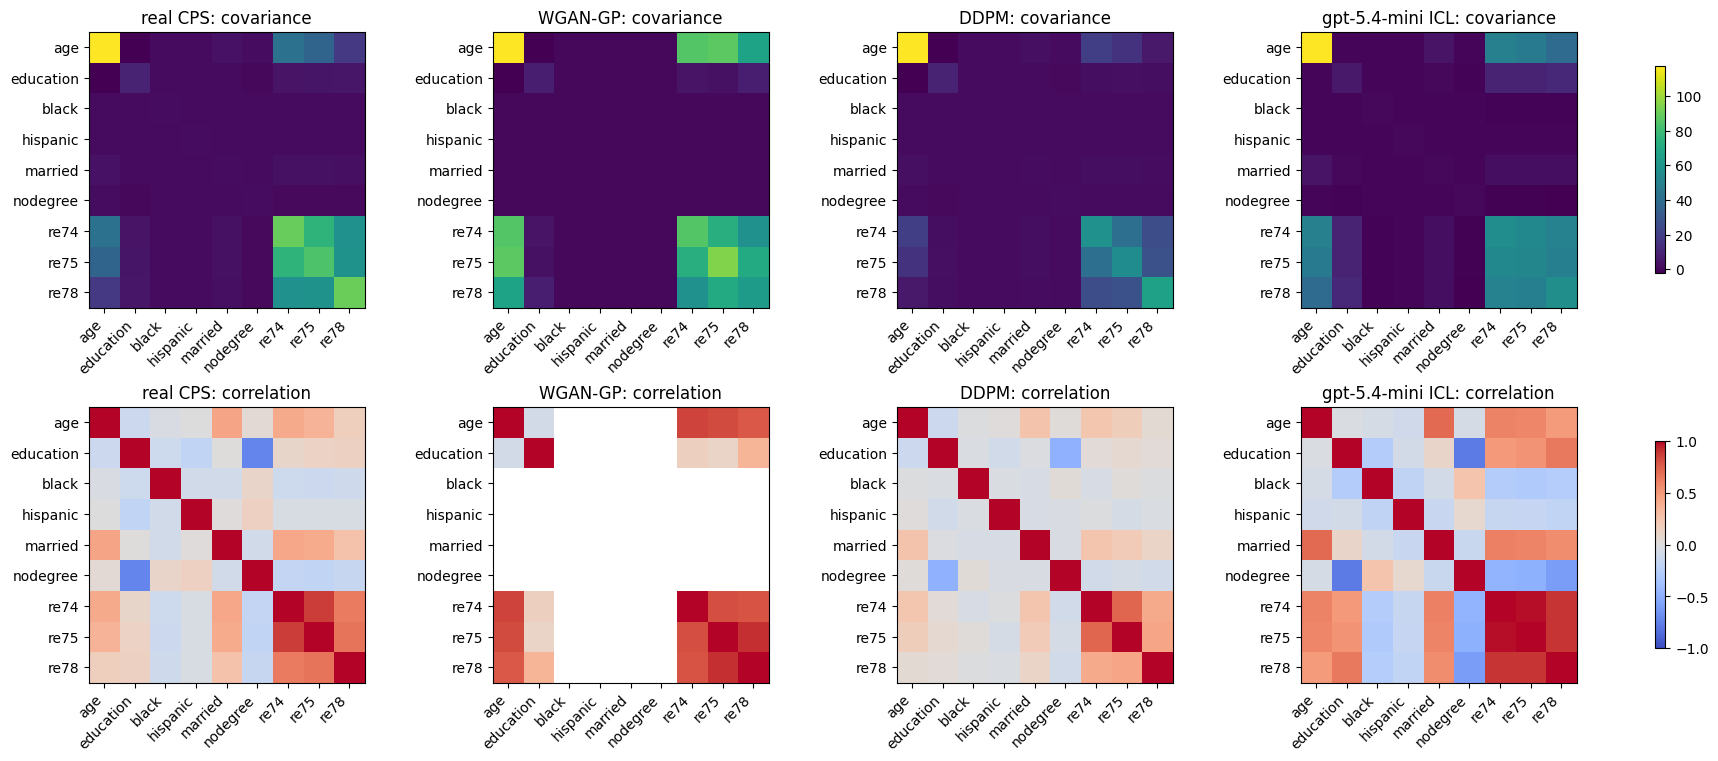

In [12]:
plot_sets = [("real CPS", real), ("WGAN-GP", wgan_df), ("DDPM", ddpm_df)]
if gptoss_df is not None:
    plot_sets.append(("gpt-5.4-mini ICL", gptoss_df))

fig, axes = plt.subplots(2, len(plot_sets), figsize=(4.4 * len(plot_sets), 7.5), constrained_layout=True)
if len(plot_sets) == 1:
    axes = np.asarray(axes).reshape(2, 1)

for j, (name, df) in enumerate(plot_sets):
    cov = covariance_matrix(df)
    corr = correlation_matrix(df)
    im0 = axes[0, j].imshow(cov, cmap="viridis")
    axes[0, j].set_title(f"{name}: covariance")
    im1 = axes[1, j].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1, j].set_title(f"{name}: correlation")
    for ax in axes[:, j]:
        ax.set_xticks(range(len(matrix_columns)))
        ax.set_xticklabels(matrix_columns, rotation=45, ha="right")
        ax.set_yticks(range(len(matrix_columns)))
        ax.set_yticklabels(matrix_columns)

fig.colorbar(im0, ax=axes[0, :], shrink=0.75, location="right")
fig.colorbar(im1, ax=axes[1, :], shrink=0.75, location="right")
plt.show()

## Earnings Scatter Check

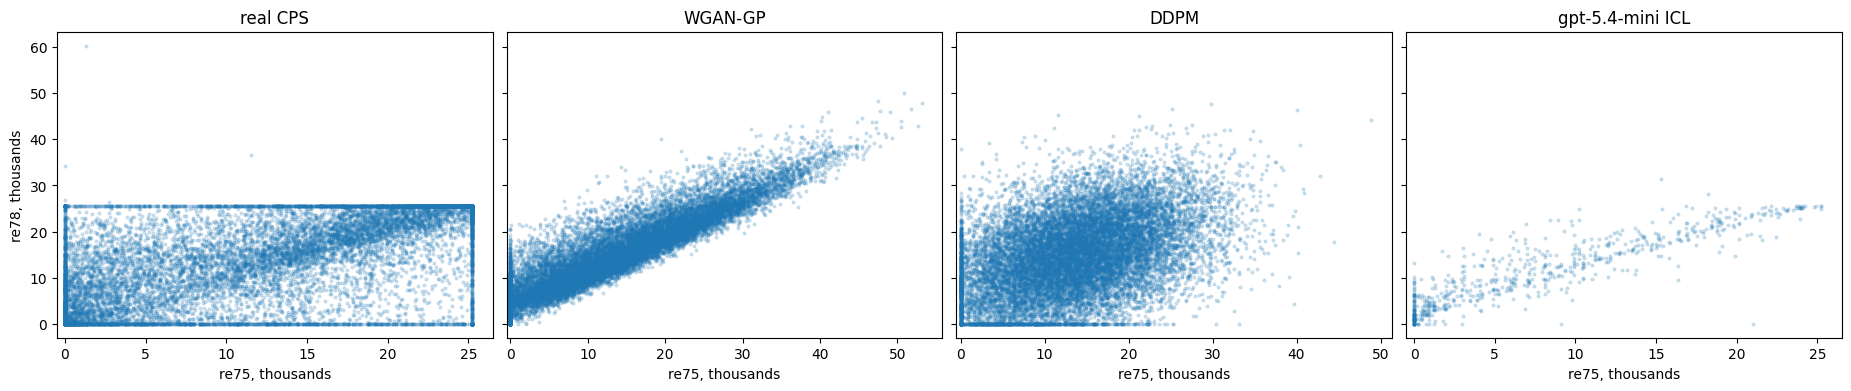

In [13]:
plot_items = [("real CPS", real), ("WGAN-GP", wgan_df), ("DDPM", ddpm_df)]
if gptoss_df is not None:
    plot_items.append(("gpt-5.4-mini ICL", gptoss_df))

fig, axes = plt.subplots(1, len(plot_items), figsize=(4.6 * len(plot_items), 3.8), sharey=True, constrained_layout=True)
if len(plot_items) == 1:
    axes = [axes]

for ax, (title, df) in zip(axes, plot_items):
    ax.scatter(df["re75"], df["re78"], s=4, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("re75, thousands")
    ax.set_xlim(left=-0.5)
axes[0].set_ylabel("re78, thousands")
plt.show()

The gpt-5.4-mini ICL block uses the observed treated count and a 500-row control cap. The cap is a runtime constraint rather than a statistical target: an API completion model is useful for a one-off prompt-completion baseline, but generating the full CPS control population this way is not practical for routine benchmarking. Interpret its ATT and distance diagnostics as a small-sample ICL stress test, not as a full synthetic-data benchmark on equal footing with WGAN and DDPM.